# Prompt Importance

**Feeds:** RQ1 (prompt sensitivity, PT vs EN). This notebook also produces
`best_templates.json`, the best-template-per-(model, language) artifact
that notebooks 02-04 depend on -- **run this notebook first**.

Uses `results/prompt_selection/{portuguese,english}/results.csv`: 8 prompt
templates (`cls`, `cls_def`, `cls_def_exp`, `cls_exp`, `ext`, `ext_def`,
`ext_def_exp`, `ext_exp`) x up to 5 models, evaluated on the 20
prompt-selection documents.


In [1]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)


In [2]:
BASE_TEMPLATES = ["cls", "cls_def",  "ext", "ext_def", "cls_def_exp", "cls_exp", "ext_def_exp", "ext_exp"]

results = pd.concat([c.load_results("prompt_selection", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
results = results[results["template"].isin(BASE_TEMPLATES) & (results["model"] != "llama32_3b")].reset_index(drop=True)
results.head(55)

,model,template,entity,precision,recall,f1,f1_r,stage,language
0,amalia,ext,participants,0.000000,0.000000,0.000000,0.066061,prompt_selection,portuguese
1,amalia,ext_def,participants,0.166667,0.001912,0.003781,0.028474,prompt_selection,portuguese
2,amalia,ext_exp,participants,0.188679,0.019120,0.034722,0.058643,prompt_selection,portuguese
3,amalia,cls_def,participants,0.180556,0.024857,0.043697,0.283443,prompt_selection,portuguese
4,amalia,ext_def_exp,participants,0.070946,0.040153,0.051282,0.121359,prompt_selection,portuguese
5,amalia,cls,participants,0.244186,0.040153,0.068966,0.231410,prompt_selection,portuguese
6,amalia,cls_exp,participants,0.148649,0.084130,0.107448,0.342763,prompt_selection,portuguese
7,amalia,cls_def_exp,participants,0.225581,0.185468,0.203568,0.455463,prompt_selection,portuguese
8,euro_llm_9b,cls,participants,0.263889,0.036329,0.063866,0.198383,prompt_selection,portuguese
9,euro_llm_9b,cls_def,participants,0.256410,0.038241,0.066556,0.311546,prompt_selection,portuguese


## Combined view: Precision/Recall/F1 distribution per template

The per-model bar charts above are informative but noisy -- each template's
signal is split across 5 models x multiple entities. Pooling across models
and entities (same `results` frame as above, already restricted to
`BASE_TEMPLATES`) into one boxplot per template isolates the template effect:
it shows whether a template (e.g. the `*_exp` family) is consistently better,
rather than better for just one model. Kept split by language (as in the bar
charts above), since PT vs EN prompt sensitivity is part of RQ1.

C:\Users\davib\AppData\Local\Temp\ipykernel_69808\996469707.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")


C:\Users\davib\AppData\Local\Temp\ipykernel_69808\996469707.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_combined_boxplot_by_template_language.pdf


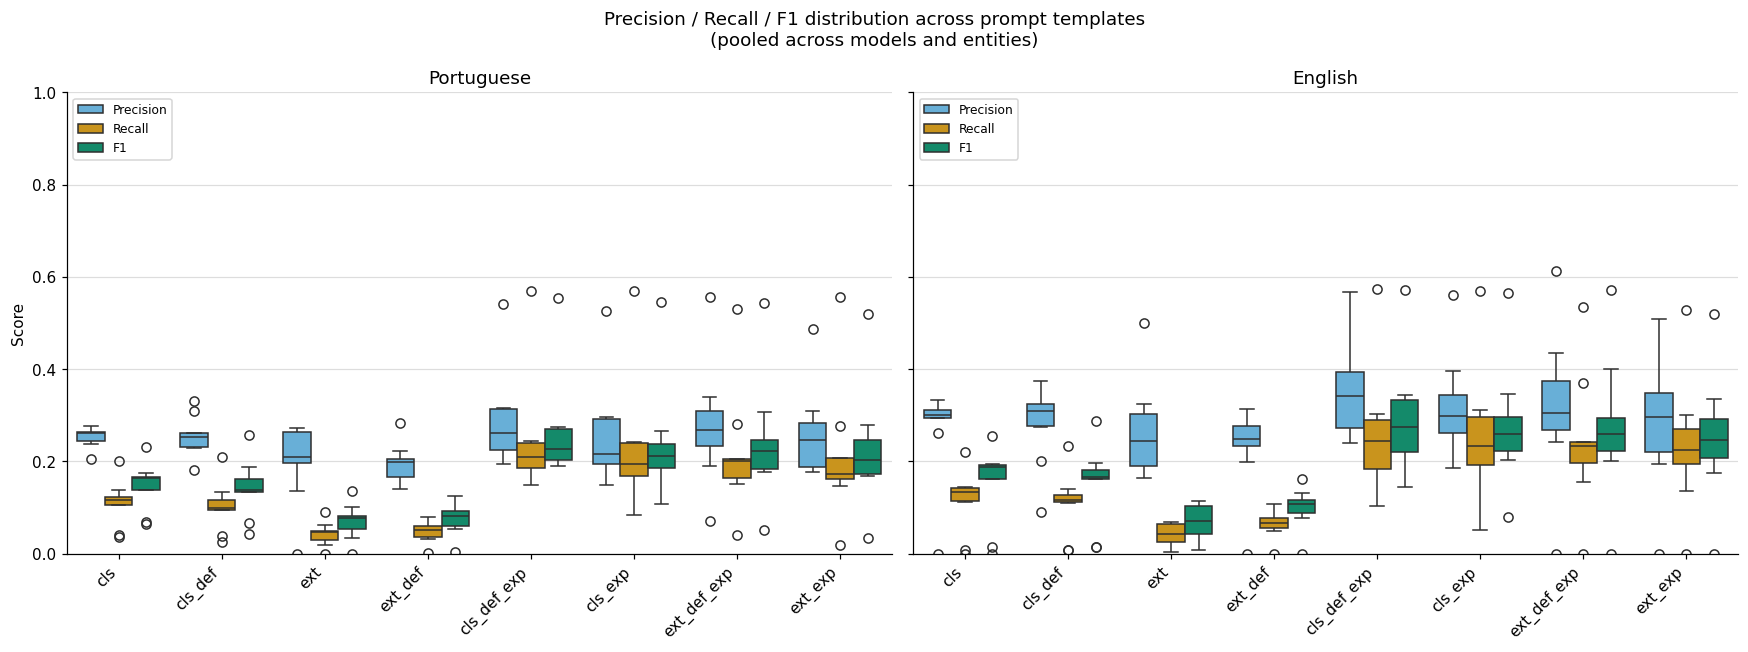

In [3]:
METRIC_ORDER = ["precision", "recall", "f1"]
METRIC_LABELS = {"precision": "Precision", "recall": "Recall", "f1": "F1"}
METRIC_COLORS = {"precision": "#56B4E9", "recall": "#E69F00", "f1": "#009E73"}

metric_long = results.melt(
    id_vars=["template", "language"],
    value_vars=METRIC_ORDER,
    var_name="metric",
    value_name="score",
)
metric_long["metric"] = metric_long["metric"].map(METRIC_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, lang in zip(axes, c.LANGUAGE_ORDER):
    sub = metric_long[metric_long["language"] == lang]
    sns.boxplot(
        data=sub,
        x="template",
        y="score",
        hue="metric",
        order=BASE_TEMPLATES,
        hue_order=[METRIC_LABELS[m] for m in METRIC_ORDER],
        palette={METRIC_LABELS[m]: METRIC_COLORS[m] for m in METRIC_ORDER},
        ax=ax,
    )
    ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")
    ax.set_title(lang.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(title=None, loc="upper left", fontsize=8)
    c.style_axis(ax)
fig.suptitle("Precision / Recall / F1 distribution across prompt templates\n(pooled across models and entities)")
c.save_fig(fig, "01_combined_boxplot_by_template_language")
plt.show()


## F1 and F1-r across templates, per model and language

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_f1_by_template_model_language.pdf


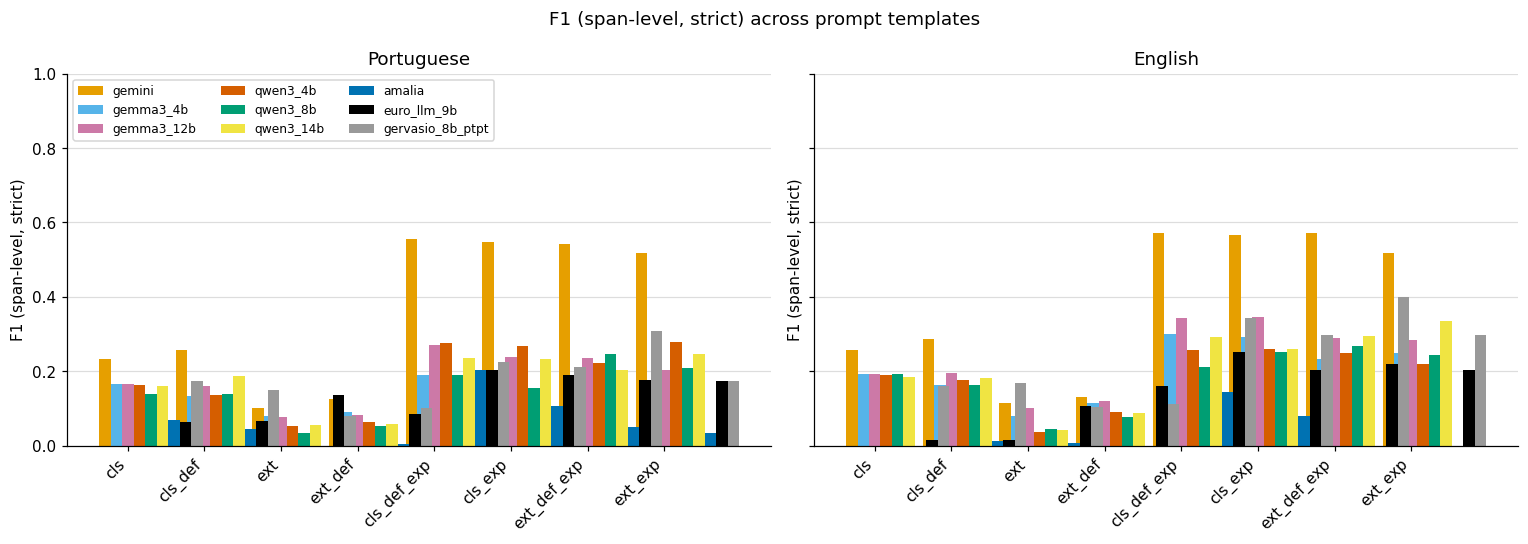

In [4]:
def plot_metric_by_template(metric, ylabel, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, lang in zip(axes, c.LANGUAGE_ORDER):
        sub = results[results["language"] == lang]
        for i, model in enumerate(c.MODEL_ORDER):
            m = sub[sub["model"] == model].set_index("template").reindex(BASE_TEMPLATES)
            x = np.arange(len(BASE_TEMPLATES)) + (i - 2) * 0.15
            ax.bar(x, m[metric].values, width=0.15, color=c.MODEL_COLORS[model], label=model)
        ax.set_xticks(np.arange(len(BASE_TEMPLATES)))
        ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")
        ax.set_title(lang.capitalize())
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1)
        c.style_axis(ax)
    axes[0].legend(loc="upper left", fontsize=8, ncol=3)
    fig.suptitle(ylabel + " across prompt templates")
    c.save_fig(fig, fname)
    plt.show()


plot_metric_by_template("f1", "F1 (span-level, strict)", "01_f1_by_template_model_language")


### Best F1 template per model

The bar chart above suggests the `*_exp` templates dominate, but that's hard
to read off 8 clustered bars per model. A heatmap of F1 by (model, template),
with each model's best template outlined, makes the pattern explicit.

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_best_template_heatmap.pdf


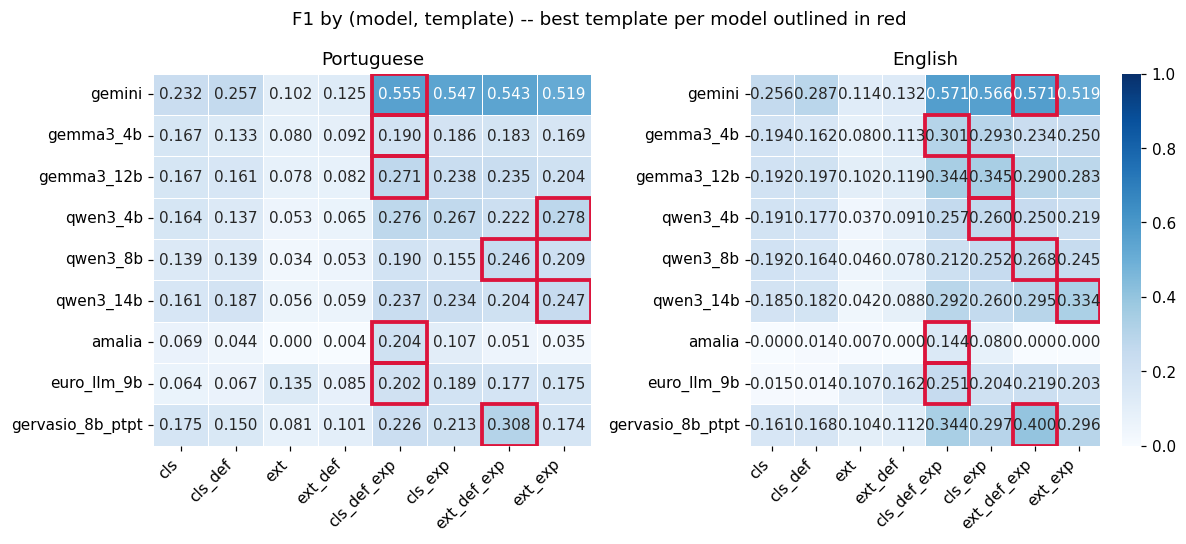

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for i, (ax, lang) in enumerate(zip(axes, c.LANGUAGE_ORDER)):
    sub = results[results["language"] == lang]
    pivot = sub.pivot(index="model", columns="template", values="f1").reindex(index=c.MODEL_ORDER, columns=BASE_TEMPLATES)
    sns.heatmap(
        pivot, ax=ax, cmap=c.HEATMAP_CMAP, vmin=0, vmax=1, annot=True, fmt=".3f",
        cbar=(i == len(c.LANGUAGE_ORDER) - 1), linewidths=0.5, linecolor="white",
    )
    for row_i, model in enumerate(pivot.index):
        col_i = pivot.loc[model].values.argmax()
        ax.add_patch(plt.Rectangle((col_i, row_i), 1, 1, fill=False, edgecolor="crimson", lw=2.5))
    ax.set_title(lang.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("F1 by (model, template) -- best template per model outlined in red")
c.save_fig(fig, "01_best_template_heatmap")
plt.show()


## Prompt sensitivity: dispersion of F1 across templates

In [6]:
disp = (
    results.groupby(["language", "model"])["f1"]
    .agg(std="std", min="min", max="max")
    .assign(range=lambda d: d["max"] - d["min"])
    .reset_index()
)
disp


,language,model,std,min,max,range
0,english,amalia,0.053256,0.000000,0.144168,0.144168
1,english,euro_llm_9b,0.092007,0.014467,0.250569,0.236103
2,english,gemini,0.201137,0.113671,0.571142,0.457471
3,english,gemma3_12b,0.095599,0.101949,0.345339,0.243390
4,english,gemma3_4b,0.080755,0.080477,0.300804,0.220327
5,english,gervasio_8b_ptpt,0.112567,0.103937,0.399594,0.295657
6,english,qwen25_14b,0.053472,0.062914,0.213018,0.150104
7,english,qwen3_14b,0.104332,0.042484,0.334463,0.291980
8,english,qwen3_4b,0.081958,0.037037,0.259835,0.222798
9,english,qwen3_8b,0.081713,0.046129,0.267682,0.221554


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_prompt_sensitivity_dispersion.pdf


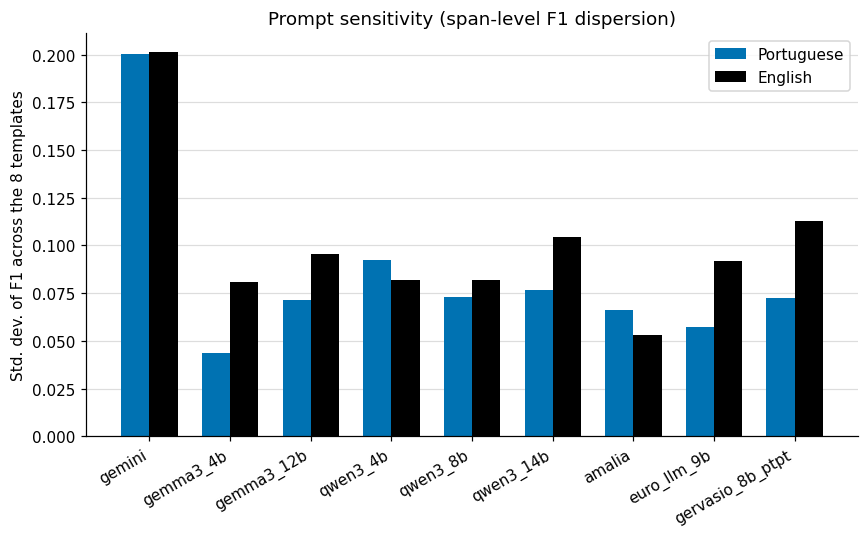

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(c.MODEL_ORDER))
width = 0.35
for i, lang in enumerate(c.LANGUAGE_ORDER):
    sub = disp[disp["language"] == lang].set_index("model").reindex(c.MODEL_ORDER)
    ax.bar(x + (i - 0.5) * width, sub["std"].values, width=width, color=c.LANGUAGE_COLORS[lang], label=lang.capitalize())
ax.set_xticks(x)
ax.set_xticklabels(c.MODEL_ORDER, rotation=30, ha="right")
ax.set_ylabel("Std. dev. of F1 across the 8 templates")
ax.set_title("Prompt sensitivity (span-level F1 dispersion)")
ax.legend()
c.style_axis(ax)
c.save_fig(fig, "01_prompt_sensitivity_dispersion")
plt.show()


## Determining the best template per (model, language)

Best template = argmax F1 only (no F1-r tie-break), for consistency with
the F1 heatmap above. Exported to `best_templates.json` for reuse by
notebooks 02-04.

In [8]:
best_rows = results.sort_values("f1", ascending=False).drop_duplicates(subset=["language", "model"], keep="first")

best_templates = {}
for lang in c.LANGUAGE_ORDER:
    lang_rows = best_rows[best_rows["language"] == lang]
    best_templates[lang] = dict(zip(lang_rows["model"], lang_rows["template"]))

best_templates

{'portuguese': {'gemini': 'cls_def_exp',
  'gervasio_8b_ptpt': 'ext_def_exp',
  'qwen3_4b': 'ext_exp',
  'gemma3_12b': 'cls_def_exp',
  'qwen3_14b': 'ext_exp',
  'qwen3_8b': 'ext_def_exp',
  'amalia': 'cls_def_exp',
  'euro_llm_9b': 'cls_def_exp',
  'gemma3_4b': 'cls_def_exp'},
 'english': {'gemini': 'ext_def_exp',
  'gervasio_8b_ptpt': 'ext_def_exp',
  'gemma3_12b': 'cls_exp',
  'qwen3_14b': 'ext_exp',
  'gemma3_4b': 'cls_def_exp',
  'qwen3_8b': 'ext_def_exp',
  'qwen3_4b': 'cls_exp',
  'euro_llm_9b': 'cls_def_exp',
  'qwen25_14b': 'cls_exp',
  'amalia': 'cls_def_exp'}}

In [9]:
path = c.save_best_templates(best_templates)
print(f"Saved best templates to {path}")


Saved best templates to C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\notebooks\results\best_templates.json


## Supplementary: temperature sensitivity in the test stage (PT and EN)

Scope of this subsection: the **test** stage only, in **both languages**. Each
model was run in the test stage on its own base template (the one selected
above), swept over decoding temperature (0.0/0.3/0.6/1.0, depending on the
model).

Test-stage run names encode the full decoding configuration as
`<template>_temp<T>_<delim>_<role>_<cot>`. For this analysis only the
**template and the temperature** matter, so everything after the temperature
is dropped and the runs that differ only in those trailing fields are averaged
into a single (template, temperature) point. Runs whose name carries no
`temp` suffix predate the sweep and used the pipeline default temperature of
0.3 (`experiments/test.py`), so they are folded into the 0.3 group.

Sweep depth is uneven: most PT models have the full 0.3/0.6/1.0 sweep,
`gemini` (PT) additionally has 0.0, while `amalia`, `qwen3_4b` and
`qwen25_14b` have a single recorded point, so no within-model sensitivity can
be read off them. In EN only `qwen3_14b` and `qwen3_8b` were swept. One
figure is produced per language.

In [10]:
DEFAULT_TEMPERATURE = 0.3  # experiments/test.py default, used by runs with no temp suffix


def load_temperature_ablation(language: str) -> pd.DataFrame:
    """Test-stage results for `language`, reduced to (model, template, temperature).

    Everything in the run name after the temperature (delim/role/CoT) is
    dropped and averaged over, since it is out of scope here.
    """
    df = c.load_results("test", language)
    df["base_template"] = df["template"].str.replace(r"_temp.*$", "", regex=True)
    df["temperature"] = (
        df["template"].str.extract(r"temp([\d.]+)")[0].astype(float).fillna(DEFAULT_TEMPERATURE)
    )
    out = df.groupby(["model", "base_template", "temperature"], as_index=False)[["f1", "f1_r"]].mean()
    out["config"] = out["base_template"] + "\nT = " + out["temperature"].map("{:.1f}".format)
    out["language"] = language
    return out


ablation = pd.concat([load_temperature_ablation(lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
ablation.sort_values(["language", "model", "temperature"]).reset_index(drop=True)

,model,base_template,temperature,f1,f1_r,config,language
0,gemini,cls_def_exp,0.3,0.540468,0.752663,cls_def_exp\nT = 0.3,english
1,qwen25_14b,cls_exp,0.3,0.228795,0.674295,cls_exp\nT = 0.3,english
2,qwen3_14b,ext_exp,0.3,0.312315,0.744568,ext_exp\nT = 0.3,english
3,qwen3_14b,ext_exp,0.6,0.308503,0.742019,ext_exp\nT = 0.6,english
4,qwen3_14b,ext_exp,1.0,0.326364,0.744568,ext_exp\nT = 1.0,english
5,qwen3_4b,cls_def_exp,0.3,0.259682,0.602385,cls_def_exp\nT = 0.3,english
6,qwen3_8b,ext_exp,0.3,0.280633,0.732744,ext_exp\nT = 0.3,english
7,qwen3_8b,ext_exp,0.6,0.285714,0.757763,ext_exp\nT = 0.6,english
8,qwen3_8b,ext_exp,1.0,0.297336,0.754793,ext_exp\nT = 1.0,english
9,amalia,cls_def_exp,0.3,0.161814,0.400753,cls_def_exp\nT = 0.3,portuguese


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_temperature_ablation_portuguese.pdf


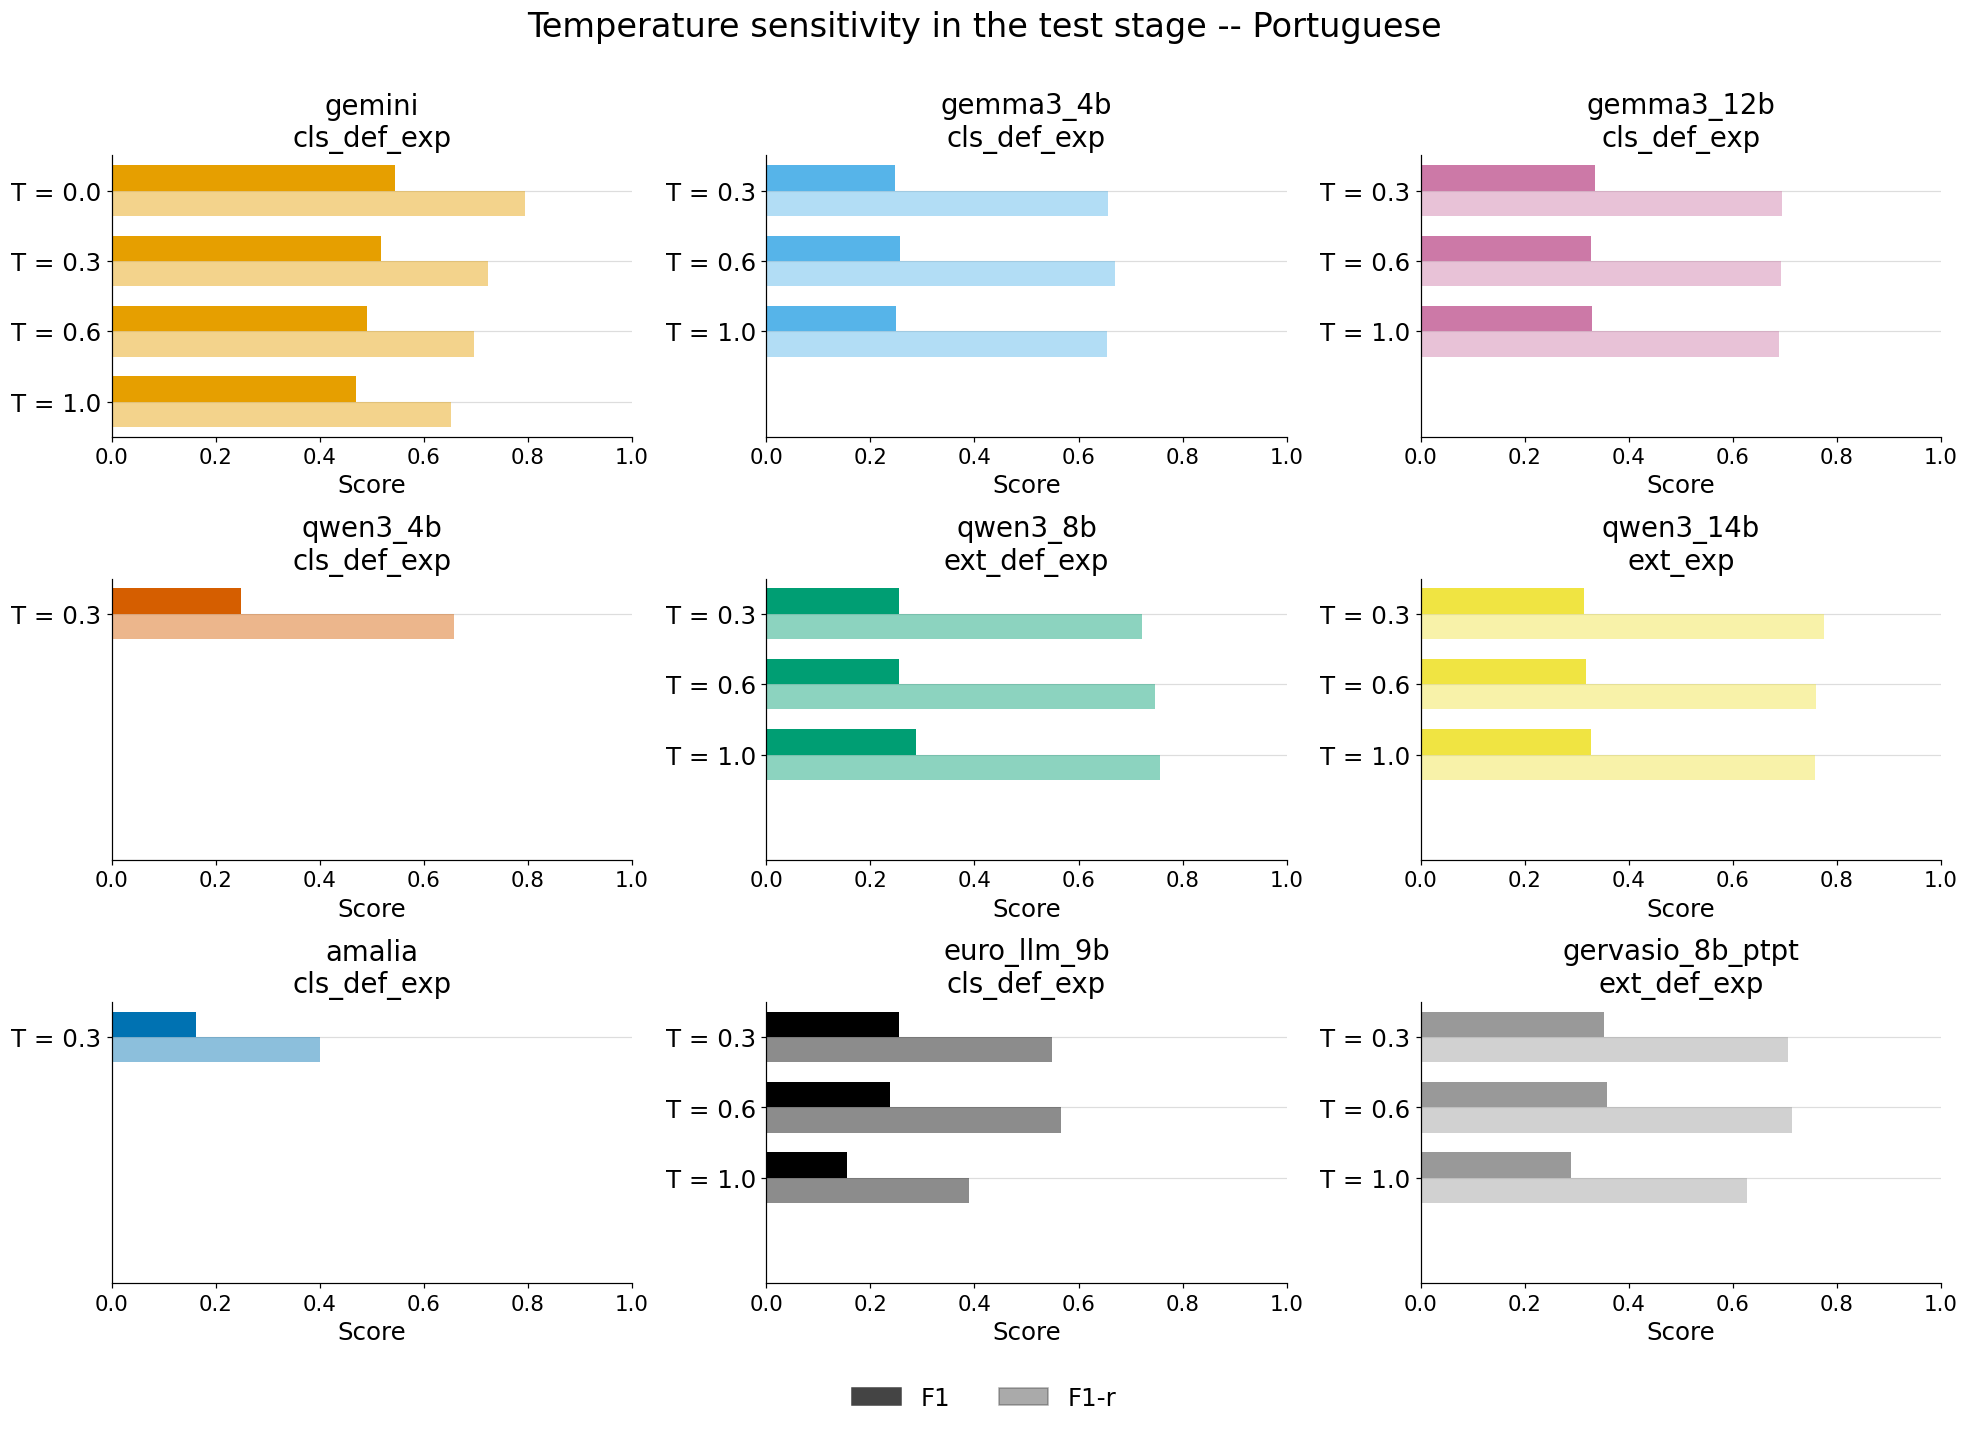

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_temperature_ablation_english.pdf


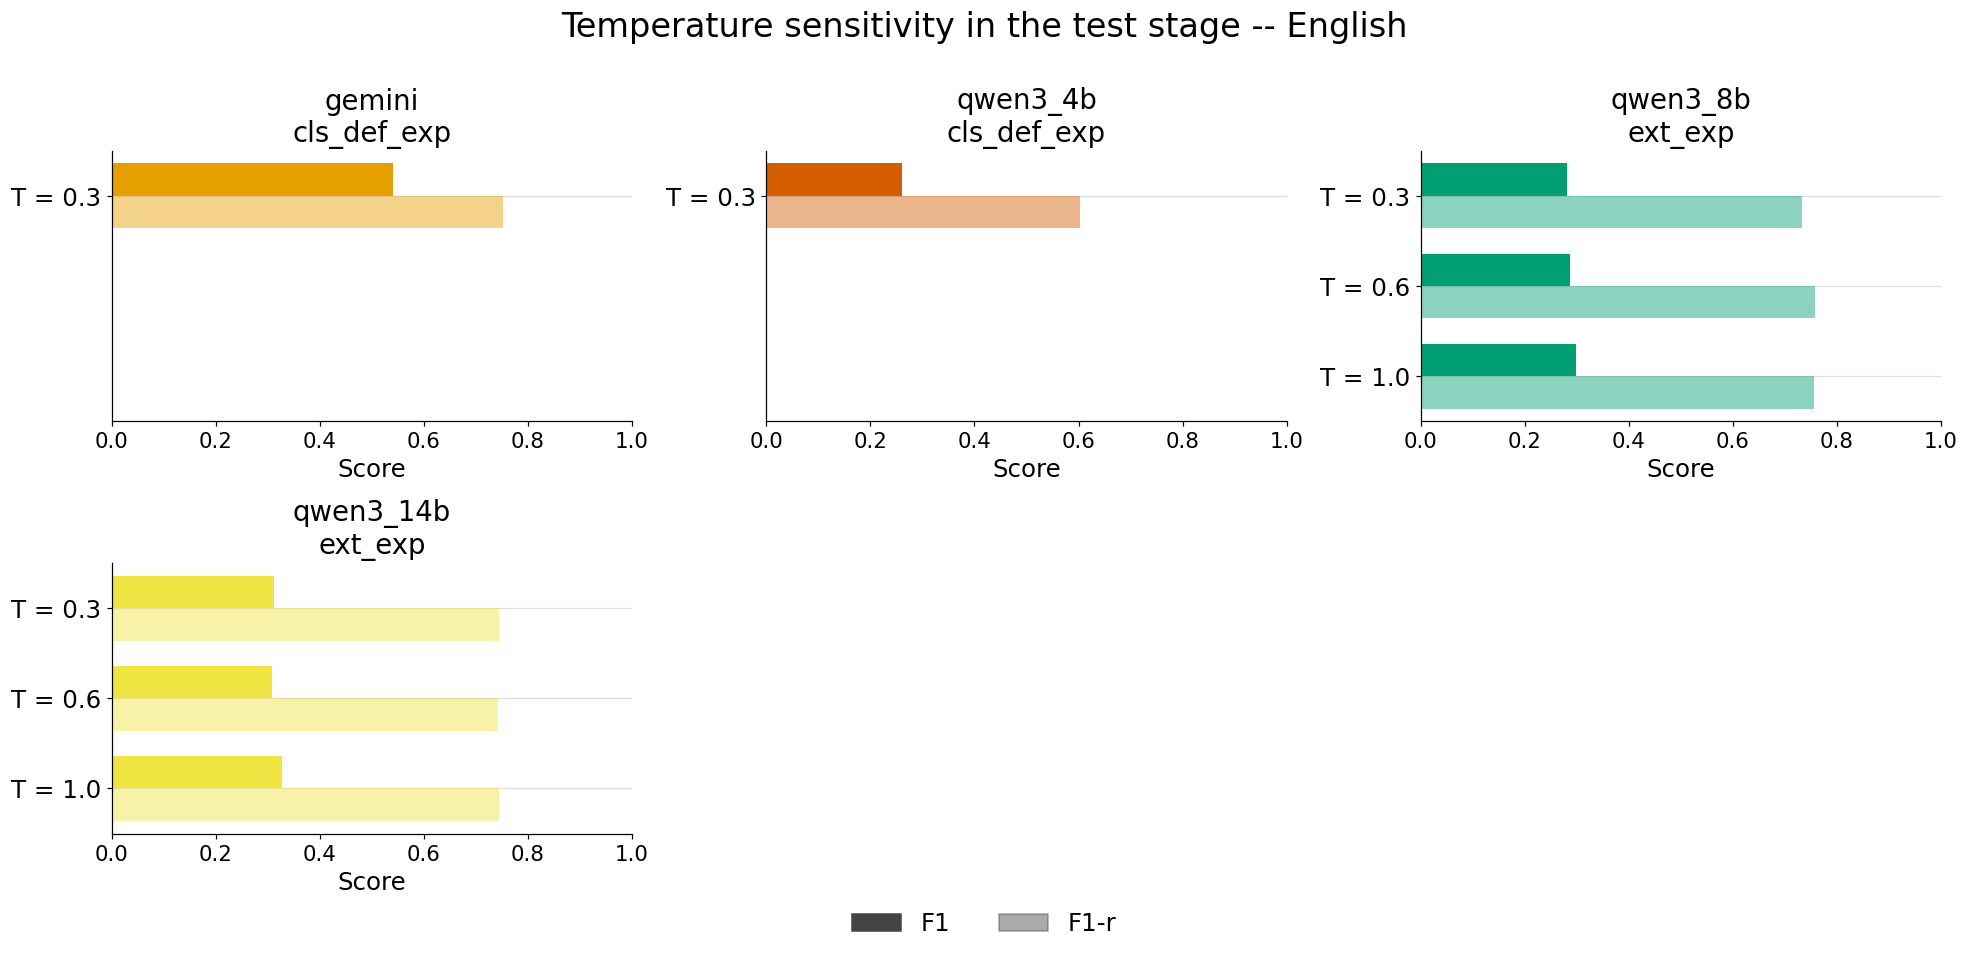

In [11]:
ABLATION_NCOLS = 3
ABLATION_MAX_ROWS = 3


def plot_temperature_ablation(language: str):
    """A 3-column grid of per-model panels for `language`, ordered by temperature.

    PT has 9 models and so fills a full 3x3; EN has fewer, so the row count
    shrinks rather than leaving whole empty rows.
    """
    sub = ablation[ablation["language"] == language]
    models = [m for m in c.MODEL_ORDER if m in set(sub["model"])][: ABLATION_MAX_ROWS * ABLATION_NCOLS]
    nrows = int(np.ceil(len(models) / ABLATION_NCOLS))
    # Shared y-range so bar thickness is comparable across panels with
    # different sweep depths (some models have a single recorded point).
    n_slots = sub[sub["model"].isin(models)].groupby("model").size().max()

    fig, axes = plt.subplots(nrows, ABLATION_NCOLS, figsize=(6.0 * ABLATION_NCOLS, 4.4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, model in zip(axes, models):
        m = sub[sub["model"] == model].sort_values("temperature")
        y = np.arange(len(m))
        h = 0.36
        ax.barh(y - h / 2, m["f1"], height=h, color=c.MODEL_COLORS[model])
        ax.barh(y + h / 2, m["f1_r"], height=h, color=c.MODEL_COLORS[model], alpha=0.45)
        ax.set_yticks(y)
        ax.set_yticklabels([f"T = {t:.1f}" for t in m["temperature"]], fontsize=16)
        ax.set_ylim(n_slots - 0.5, -0.5)  # lowest temperature on top
        ax.set_xlabel("Score", fontsize=16)
        ax.set_xlim(0, 1)
        ax.tick_params(axis="x", labelsize=14)
        ax.set_title(f"{model}\n{m['base_template'].iloc[0]}", fontsize=18)
        c.style_axis(ax)

    for ax in axes[len(models):]:
        ax.axis("off")

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color="#444444", label="F1"),
        plt.Rectangle((0, 0), 1, 1, color="#444444", alpha=0.45, label="F1-r"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=16, frameon=False)
    fig.suptitle(f"Temperature sensitivity in the test stage -- {language.capitalize()}", fontsize=22)
    fig.tight_layout(rect=(0, 0.05, 1, 0.97))
    c.save_fig(fig, f"01_temperature_ablation_{language}", tight=False)
    plt.show()


for lang in c.LANGUAGE_ORDER:
    plot_temperature_ablation(lang)

## Synthesis

- Feeds **RQ1**: the `*_exp` templates (`cls_exp`, `cls_def_exp`, `ext_exp`, `ext_def_exp`) take the four highest
  median-F1 ranks out of the 8 templates, in both languages (see the heatmap and the combined
  boxplot) -- and are the argmax-F1 best template for every one of the 4 models, in both
  languages (`best_templates.json` below). Adding a worked example to the prompt is the single
  largest lever on span-extraction reliability observed here, ahead of adding a class definition
  or switching between classify (`cls_*`) and extract (`ext_*`) framing.
- Prompt sensitivity (F1 std/range across the 8 templates) is highest for `gemini` (std ~0.20,
  range ~0.45-0.51) and lowest for `qwen25_14b` and `gemma3_1b` (std ~0.05-0.08) in both
  languages -- larger/more capable does not mean less prompt-sensitive here; `qwen3_4b` sits in
  between (std ~0.08-0.09).
- `best_templates.json` now holds the best (model, language) template pair -- argmax F1 only, no
  F1-r tie-break, for consistency with the heatmap -- consumed by notebooks 02-04.
- The test-stage temperature sweep (PT and EN) gives a secondary read on how much of each model's
  variance is prompt-*content* sensitivity (this section) vs. decoding-*temperature* sensitivity.
  Temperature moves F1 far less than template choice does: within a model the 0.3-1.0 spread is
  typically a few F1 points, against the ~0.20-0.45 range seen across templates. `gemini` (PT)
  degrades monotonically with temperature (0.54 at T=0.0 down to 0.47 at T=1.0), while the qwen3
  models are flat or mildly *improved* at higher temperature. Sweep depth is uneven (four
  temperatures for `gemini` PT, three for most PT models, a single point for `amalia`,
  `qwen3_4b` and both EN non-qwen3 runs), so cross-model comparisons here are qualitative, not a
  controlled ablation.
- `llama32_3b` is excluded throughout (see the note at the top of this notebook and
  `_common.EXCLUDED_MODELS`): its results are invalid, not just weak.
- Numeric interpretation to be condensed into `report/Chapters/Results.tex` prose in a future
  iteration (see the plan's RQ map).